In [1]:
import pandas as pd

In [12]:
all_variants = pd.read_csv("../data/all_sites_fixed.txt", sep="\t", header=None, dtype={4: str})
all_variants = all_variants[all_variants[3] != "."]
all_variants

,0,1,2,3,4
0,chr1,999064,G,A,10
1,chr1,999064,G,C,10
3,chr1,999071,C,T,10
5,chr1,999072,G,C,11
6,chr1,999080,G,A,11
...,...,...,...,...,...
945520,chrY,3579738,C,G,11
945521,chrY,3579754,A,C,10
945524,chrY,3579783,C,A,10
945526,chrY,3579785,A,G,11


In [15]:
all_variants[0].value_counts()

0
chr19    104890
chr1      46387
chr16     33249
chr2      30704
chr7      30253
chr6      26581
chr12     24502
chr9      23206
chr17     22128
chr20     21220
chr3      20999
chr8      18429
chr11     18368
chr4      14320
chr10     14042
chr5      13890
chr18     13062
chr15     12401
chr14     11038
chrX      10283
chr13      7028
chr22      6773
chr21      5181
chrY        253
Name: count, dtype: int64

In [16]:
# VCF positions are 1 indexed, inclusive
# Changing to bed format
all_variants["start"] = all_variants[1] - 1
all_variants["end"] = all_variants[1]
all_variants

,0,1,2,3,4,start,end
0,chr1,999064,G,A,10,999063,999064
1,chr1,999064,G,C,10,999063,999064
3,chr1,999071,C,T,10,999070,999071
5,chr1,999072,G,C,11,999071,999072
6,chr1,999080,G,A,11,999079,999080
...,...,...,...,...,...,...,...
945520,chrY,3579738,C,G,11,3579737,3579738
945521,chrY,3579754,A,C,10,3579753,3579754
945524,chrY,3579783,C,A,10,3579782,3579783
945526,chrY,3579785,A,G,11,3579784,3579785


In [17]:
all_variants["chr"] = all_variants[0].str.split("chr").str[1]
all_variants

,0,1,2,3,4,start,end,chr
0,chr1,999064,G,A,10,999063,999064,1
1,chr1,999064,G,C,10,999063,999064,1
3,chr1,999071,C,T,10,999070,999071,1
5,chr1,999072,G,C,11,999071,999072,1
6,chr1,999080,G,A,11,999079,999080,1
...,...,...,...,...,...,...,...,...
945520,chrY,3579738,C,G,11,3579737,3579738,Y
945521,chrY,3579754,A,C,10,3579753,3579754,Y
945524,chrY,3579783,C,A,10,3579782,3579783,Y
945526,chrY,3579785,A,G,11,3579784,3579785,Y


In [18]:
all_variants[4].value_counts()

4
10    319390
11    185297
01     24500
Name: count, dtype: int64

In [19]:
all_variants["proband"] = all_variants[4].str[0].astype(int).astype(bool)
all_variants["sibling"] = all_variants[4].str[1].astype(int).astype(bool)
all_variants

,0,1,2,3,4,start,end,chr,proband,sibling
0,chr1,999064,G,A,10,999063,999064,1,True,False
1,chr1,999064,G,C,10,999063,999064,1,True,False
3,chr1,999071,C,T,10,999070,999071,1,True,False
5,chr1,999072,G,C,11,999071,999072,1,True,True
6,chr1,999080,G,A,11,999079,999080,1,True,True
...,...,...,...,...,...,...,...,...,...,...
945520,chrY,3579738,C,G,11,3579737,3579738,Y,True,True
945521,chrY,3579754,A,C,10,3579753,3579754,Y,True,False
945524,chrY,3579783,C,A,10,3579782,3579783,Y,True,False
945526,chrY,3579785,A,G,11,3579784,3579785,Y,True,True


In [20]:
all_variants[["proband", "sibling"]].value_counts()

proband  sibling
True     False      319390
         True       185297
False    True        24500
Name: count, dtype: int64

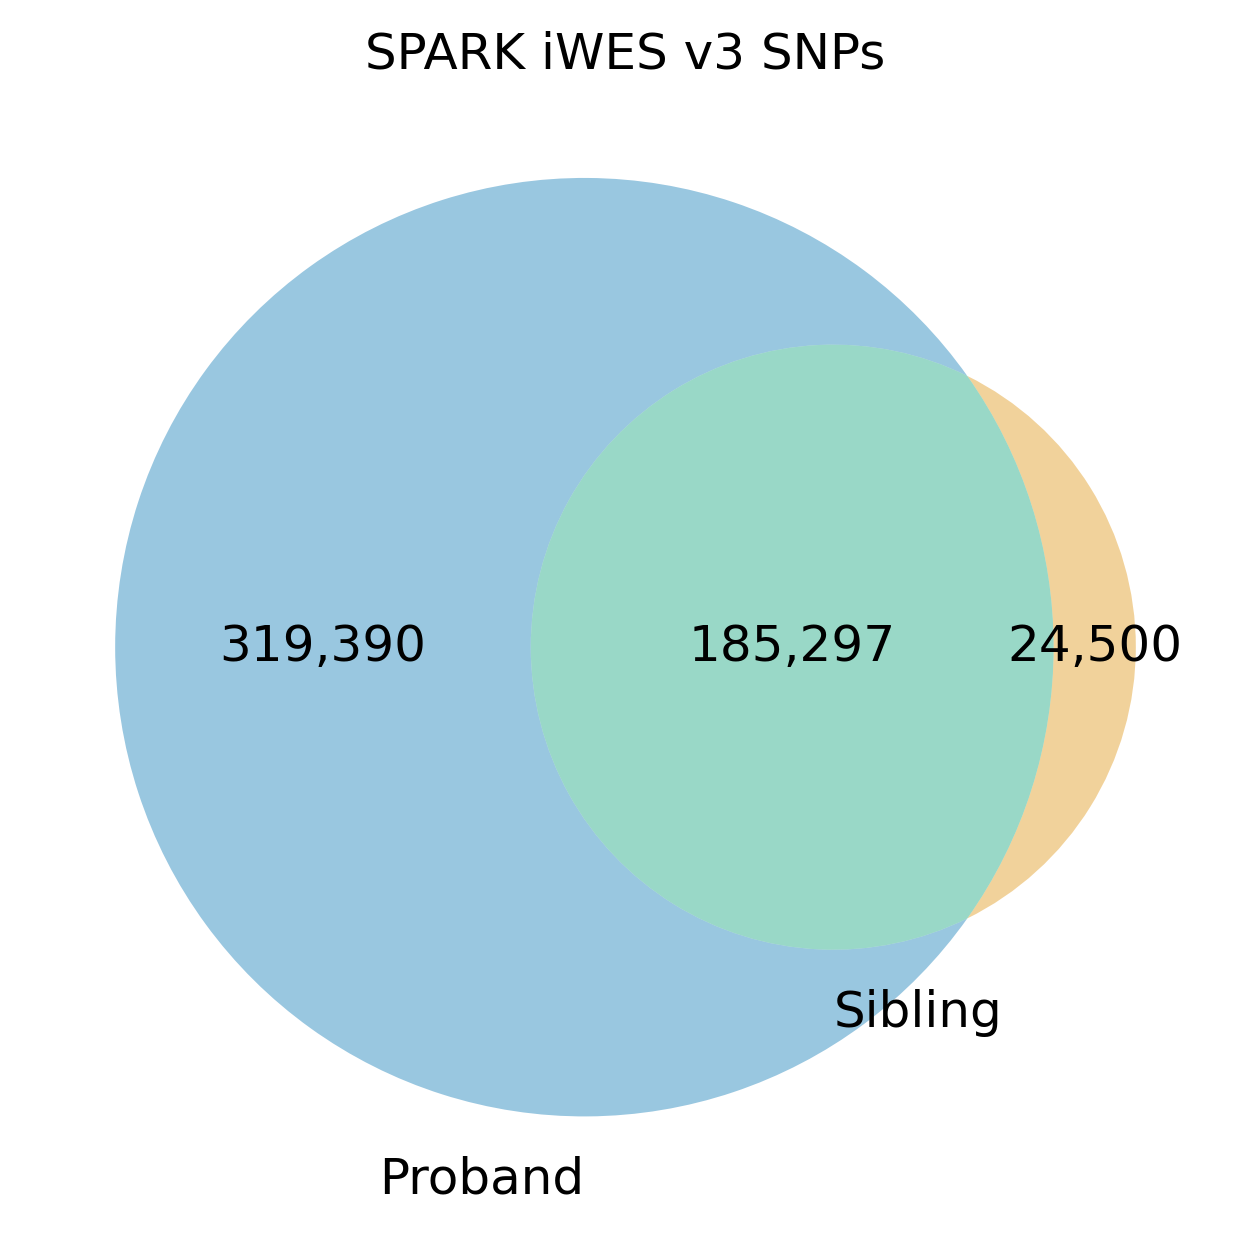

In [38]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import seaborn as sns

# Get the counts for the Venn diagram
value_counts = all_variants[["proband", "sibling"]].value_counts()

# Extract the counts for the sets
proband_only_count = value_counts.get((True, False), 0)
sibling_only_count = value_counts.get((False, True), 0)
both_count = value_counts.get((True, True), 0)

# Create the Venn diagram
#venn2(subsets=(proband_only_count, sibling_only_count, both_count), set_labels=("Proband", "Sibling"))

venn2_circles = venn2(
    subsets=(proband_only_count, sibling_only_count, both_count), 
    set_labels=("Proband", "Sibling")
)

# Format the counts as strings and add them to the diagram
venn2_circles.get_label_by_id('10').set_text(f"{proband_only_count:,}")
venn2_circles.get_label_by_id('01').set_text(f"{sibling_only_count:,}")
venn2_circles.get_label_by_id('11').set_text(f"{both_count:,}")

# Adjust font size for better fit

for label in venn2_circles.subset_labels:
    if label:
        label.set_fontsize(12)
colors = sns.color_palette('colorblind')

for subset_id, color in zip(['10', '01', '11'], colors[:3]):
    patch = venn2_circles.get_patch_by_id(subset_id)
    patch.set_color(color)
    patch.set_edgecolor("none")  # remove border


# Display the plot with dpi 300
plt.gcf().set_dpi(300)
plt.title("SPARK iWES v3 SNPs")
plt.show()

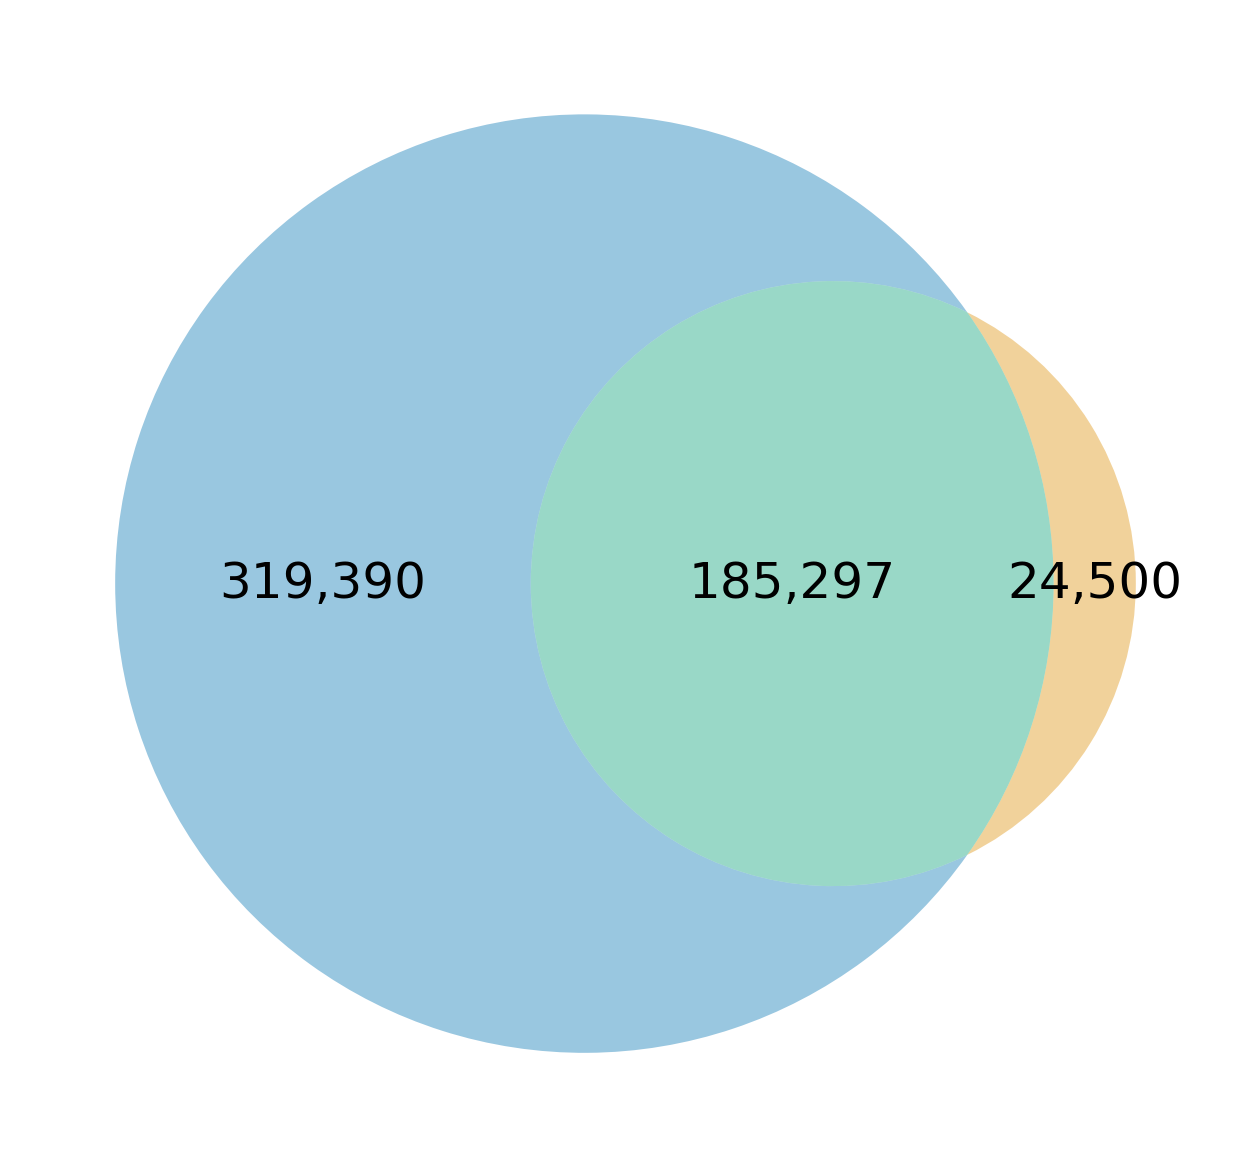

In [39]:
# Get the counts for the Venn diagram
value_counts = all_variants[["proband", "sibling"]].value_counts()

# Extract the counts for the sets
proband_only_count = value_counts.get((True, False), 0)
sibling_only_count = value_counts.get((False, True), 0)
both_count = value_counts.get((True, True), 0)

# Create the Venn diagram
#venn2(subsets=(proband_only_count, sibling_only_count, both_count), set_labels=("Proband", "Sibling"))

venn2_circles = venn2(
    subsets=(proband_only_count, sibling_only_count, both_count), 
    set_labels=("", "")
)

# Format the counts as strings and add them to the diagram
venn2_circles.get_label_by_id('10').set_text(f"{proband_only_count:,}")
venn2_circles.get_label_by_id('01').set_text(f"{sibling_only_count:,}")
venn2_circles.get_label_by_id('11').set_text(f"{both_count:,}")

# Adjust font size for better fit

for label in venn2_circles.subset_labels:
    if label:
        label.set_fontsize(12)
colors = sns.color_palette('colorblind')

for subset_id, color in zip(['10', '01', '11'], colors[:3]):
    patch = venn2_circles.get_patch_by_id(subset_id)
    patch.set_color(color)
    patch.set_edgecolor("none")  # remove border


# Display the plot with dpi 300
plt.gcf().set_dpi(300)
plt.show()

In [22]:
all_proband = all_variants[all_variants["proband"]]
all_proband

,0,1,2,3,4,start,end,chr,proband,sibling
0,chr1,999064,G,A,10,999063,999064,1,True,False
1,chr1,999064,G,C,10,999063,999064,1,True,False
3,chr1,999071,C,T,10,999070,999071,1,True,False
5,chr1,999072,G,C,11,999071,999072,1,True,True
6,chr1,999080,G,A,11,999079,999080,1,True,True
...,...,...,...,...,...,...,...,...,...,...
945520,chrY,3579738,C,G,11,3579737,3579738,Y,True,True
945521,chrY,3579754,A,C,10,3579753,3579754,Y,True,False
945524,chrY,3579783,C,A,10,3579782,3579783,Y,True,False
945526,chrY,3579785,A,G,11,3579784,3579785,Y,True,True


In [28]:
all_proband_bed = all_proband[["chr", "start", "end",  2, 3]]
all_proband_bed["af"] = 0
all_proband_bed.to_csv("../soto_analysis/raw_files/all_probands_fixed.bed", header = None, index = 0, sep = "\t")
all_proband_bed

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_22353/463185241.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_proband_bed["af"] = 0


,chr,start,end,2,3,af
0,1,999063,999064,G,A,0
1,1,999063,999064,G,C,0
3,1,999070,999071,C,T,0
5,1,999071,999072,G,C,0
6,1,999079,999080,G,A,0
...,...,...,...,...,...,...
945520,Y,3579737,3579738,C,G,0
945521,Y,3579753,3579754,A,C,0
945524,Y,3579782,3579783,C,A,0
945526,Y,3579784,3579785,A,G,0


In [29]:
all_sibling = all_variants[all_variants["sibling"]]
all_sibling

,0,1,2,3,4,start,end,chr,proband,sibling
5,chr1,999072,G,C,11,999071,999072,1,True,True
6,chr1,999080,G,A,11,999079,999080,1,True,True
9,chr1,999105,G,A,11,999104,999105,1,True,True
10,chr1,999107,C,T,11,999106,999107,1,True,True
11,chr1,999108,C,G,11,999107,999108,1,True,True
...,...,...,...,...,...,...,...,...,...,...
945515,chrY,3579720,G,C,11,3579719,3579720,Y,True,True
945518,chrY,3579731,C,T,11,3579730,3579731,Y,True,True
945519,chrY,3579733,A,C,11,3579732,3579733,Y,True,True
945520,chrY,3579738,C,G,11,3579737,3579738,Y,True,True


In [30]:
all_sibling_bed = all_sibling[["chr", "start", "end",  2, 3]]
all_sibling_bed["af"] = 0
all_sibling_bed.to_csv("../soto_analysis/raw_files/all_siblings_fixed.bed", header = None, index = 0, sep = "\t")
all_sibling_bed

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_22353/726704720.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_sibling_bed["af"] = 0


,chr,start,end,2,3,af
5,1,999071,999072,G,C,0
6,1,999079,999080,G,A,0
9,1,999104,999105,G,A,0
10,1,999106,999107,C,T,0
11,1,999107,999108,C,G,0
...,...,...,...,...,...,...
945515,Y,3579719,3579720,G,C,0
945518,Y,3579730,3579731,C,T,0
945519,Y,3579732,3579733,A,C,0
945520,Y,3579737,3579738,C,G,0


In [31]:
proband_only = all_proband[~all_proband["sibling"]]
proband_only

,0,1,2,3,4,start,end,chr,proband,sibling
0,chr1,999064,G,A,10,999063,999064,1,True,False
1,chr1,999064,G,C,10,999063,999064,1,True,False
3,chr1,999071,C,T,10,999070,999071,1,True,False
7,chr1,999104,C,G,10,999103,999104,1,True,False
17,chr1,999121,G,A,10,999120,999121,1,True,False
...,...,...,...,...,...,...,...,...,...,...
945513,chrY,3579716,C,T,10,3579715,3579716,Y,True,False
945516,chrY,3579730,C,T,10,3579729,3579730,Y,True,False
945521,chrY,3579754,A,C,10,3579753,3579754,Y,True,False
945524,chrY,3579783,C,A,10,3579782,3579783,Y,True,False


In [32]:
proband_only_bed = proband_only[["chr", "start", "end",  2, 3]]
proband_only_bed["af"] = 0
proband_only_bed.to_csv("../soto_analysis/raw_files/probands_only_fixed.bed", header = None, index = 0, sep = "\t")
proband_only_bed

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_22353/3494229677.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  proband_only_bed["af"] = 0


,chr,start,end,2,3,af
0,1,999063,999064,G,A,0
1,1,999063,999064,G,C,0
3,1,999070,999071,C,T,0
7,1,999103,999104,C,G,0
17,1,999120,999121,G,A,0
...,...,...,...,...,...,...
945513,Y,3579715,3579716,C,T,0
945516,Y,3579729,3579730,C,T,0
945521,Y,3579753,3579754,A,C,0
945524,Y,3579782,3579783,C,A,0


In [33]:
sibling_only = all_sibling[~all_sibling["proband"]]
sibling_only

,0,1,2,3,4,start,end,chr,proband,sibling
61,chr1,999186,G,A,01,999185,999186,1,False,True
64,chr1,999190,G,A,01,999189,999190,1,False,True
89,chr1,999225,G,A,01,999224,999225,1,False,True
91,chr1,999226,C,T,01,999225,999226,1,False,True
99,chr1,999245,G,T,01,999244,999245,1,False,True
...,...,...,...,...,...,...,...,...,...,...
945223,chrY,2976711,G,T,01,2976710,2976711,Y,False,True
945246,chrY,2978013,C,A,01,2978012,2978013,Y,False,True
945252,chrY,2978026,G,A,01,2978025,2978026,Y,False,True
945254,chrY,2978034,G,T,01,2978033,2978034,Y,False,True


In [34]:
sibling_only_bed = sibling_only[["chr", "start", "end",  2, 3]]
sibling_only_bed["af"] = 0
sibling_only_bed.to_csv("../soto_analysis/raw_files/siblings_only_fixed.bed", header = None, index = 0, sep = "\t")
sibling_only_bed

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_22353/528340507.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sibling_only_bed["af"] = 0


,chr,start,end,2,3,af
61,1,999185,999186,G,A,0
64,1,999189,999190,G,A,0
89,1,999224,999225,G,A,0
91,1,999225,999226,C,T,0
99,1,999244,999245,G,T,0
...,...,...,...,...,...,...
945223,Y,2976710,2976711,G,T,0
945246,Y,2978012,2978013,C,A,0
945252,Y,2978025,2978026,G,A,0
945254,Y,2978033,2978034,G,T,0
